In [1]:
import pandas as pd 

In [8]:
df = pd.read_csv(r'E:\SHM_ML\data\cleaned\cleaned_data.csv', index_col=0)

In [9]:
df

,f3,f5,f6,f9,f10,f11,f12,f13,tBD31A,rhBD31A,tVL,rhVL,vpVL,raVL,wsVL,wdVL
timestamp,,,,,,,,,,,,,,,,
2018-10-01 00:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,10.100000,81.000000,10.825000,89.333336,1159.144738,0.0,9.40,293.00
2018-10-01 01:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,10.000000,85.000000,10.241667,92.750000,1157.524605,0.1,10.30,295.00
2018-10-01 02:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,9.900000,91.000000,10.150000,92.000000,1141.142430,0.0,10.40,284.00
2018-10-01 03:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,9.800000,89.000000,10.166666,91.083336,1131.033604,0.3,11.60,296.00
2018-10-01 04:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,9.800000,90.000000,9.558333,93.166664,1110.625906,0.2,9.60,283.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-01-15 19:00:00,1.888801,2.555565,2.986277,4.078602,4.386448,4.942893,5.440576,6.436793,9.641429,83.304917,8.386441,83.342373,918.137648,0.0,1.96,200.08
2020-01-15 20:00:00,1.887610,2.586921,2.982070,4.080208,4.386448,4.940309,5.426145,6.398893,9.143141,80.168936,7.545000,84.875000,882.549401,0.0,1.51,187.83
2020-01-15 21:00:00,1.886253,2.581889,2.987133,4.078480,4.386448,4.908271,5.432978,6.410531,8.795149,82.076947,6.301667,89.455000,853.705976,0.0,1.07,199.95


In [10]:
df_sperate = df['2018-10-01':'2019-04-30']

In [11]:
df_sperate

,f3,f5,f6,f9,f10,f11,f12,f13,tBD31A,rhBD31A,tVL,rhVL,vpVL,raVL,wsVL,wdVL
timestamp,,,,,,,,,,,,,,,,
2018-10-01 00:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,10.100000,81.000000,10.825000,89.333336,1159.144738,0.0,9.400000,293.000000
2018-10-01 01:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,10.000000,85.000000,10.241667,92.750000,1157.524605,0.1,10.300000,295.000000
2018-10-01 02:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,9.900000,91.000000,10.150000,92.000000,1141.142430,0.0,10.400000,284.000000
2018-10-01 03:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,9.800000,89.000000,10.166666,91.083336,1131.033604,0.3,11.600000,296.000000
2018-10-01 04:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,9.800000,90.000000,9.558333,93.166664,1110.625906,0.2,9.600000,283.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-04-29 19:00:00,1.890049,2.594095,2.917152,4.101670,4.293515,4.813300,5.305633,6.288173,14.994566,61.665304,13.178333,67.000000,1015.313621,0.0,2.696087,314.663666
2019-04-29 20:00:00,1.895998,2.574052,2.911005,4.107677,4.293515,4.813300,5.305633,6.298710,14.102020,63.418778,12.211667,70.000000,995.619229,0.0,2.539050,319.833069
2019-04-29 21:00:00,1.890448,2.594953,2.916761,4.103926,4.293515,4.839047,5.323376,6.293116,13.356834,68.153272,11.321667,75.833336,1016.990289,0.0,2.156045,321.044067


In [12]:
freq_cols = ['f3', 'f5', 'f6', 'f9', 'f10', 'f11', 'f12', 'f13']
env_cols = ['tBD31A', 'rhBD31A', 'tVL', 'rhVL', 'vpVL', 'raVL', 'wsVL', 'wdVL']

# Training slice — pre-damage normal period
x_train = df[env_cols].loc['2018-10-01':'2019-04-30']
y_train = df[freq_cols].loc['2018-10-01':'2019-04-30']

# Train one Random Forest per frequency
from sklearn.ensemble import RandomForestRegressor

# Train one model per frequency mode
models = {}
for col in freq_cols:
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(x_train, y_train[col])
    models[col] = rf
    print(f"Trained model for {col}")

print("\nAll models trained.")


# Predict for ENTIRE dataset
predictions = {}
for col in freq_cols:
    predictions[col] = models[col].predict(df[env_cols])

pred_df = pd.DataFrame(predictions, index=df.index)

# Residuals for ENTIRE dataset
residuals_df = df[freq_cols] - pred_df

Trained model for f3
Trained model for f5
Trained model for f6
Trained model for f9
Trained model for f10
Trained model for f11
Trained model for f12
Trained model for f13

All models trained.


In [13]:
print(residuals_df.head())


                           f3        f5        f6        f9       f10  \
timestamp                                                               
2018-10-01 00:00:00 -0.001569  0.000602 -0.000643 -0.001125 -0.001464   
2018-10-01 01:00:00 -0.001015  0.000557 -0.000220 -0.000751 -0.000483   
2018-10-01 02:00:00 -0.000645  0.000290 -0.000222 -0.000613 -0.001403   
2018-10-01 03:00:00 -0.000786  0.000347 -0.000296 -0.000762 -0.001085   
2018-10-01 04:00:00 -0.000882  0.001238 -0.000511  0.000023 -0.000863   

                          f11       f12       f13  
timestamp                                          
2018-10-01 00:00:00 -0.012923  0.000804 -0.001559  
2018-10-01 01:00:00 -0.010297  0.000630 -0.000072  
2018-10-01 02:00:00 -0.011089  0.000354 -0.001643  
2018-10-01 03:00:00 -0.002750 -0.000367 -0.001405  
2018-10-01 04:00:00 -0.003769  0.000116 -0.000110  


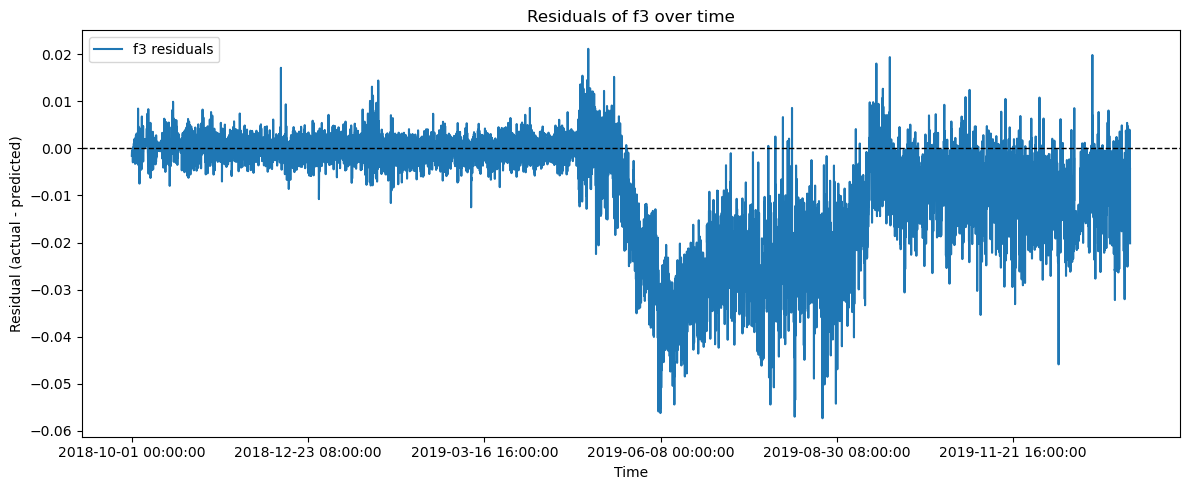

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
residuals_df['f3'].plot(label='f3 residuals')
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.title('Residuals of f3 over time')
plt.xlabel('Time')
plt.ylabel('Residual (actual - predicted)')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# imports
# ===== 1. Imports =====
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ── Clip residuals at ±3 std (training period stats only) ───────────────────
train_period = residuals_df.loc['2018-10-01':'2019-04-30']
train_mean   = train_period.mean()
train_std    = train_period.std()

lower = train_mean - 3 * train_std
upper = train_mean + 3 * train_std

residuals_clipped = residuals_df.clip(lower=lower, upper=upper, axis=1)

# ── Prepare train / full arrays ──────────────────────────────────────────────
X_full  = residuals_clipped.values
X_train = residuals_clipped.loc['2018-10-01':'2019-04-30'].values

# ── Scale ────────────────────────────────────────────────────────────────────
scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)   # fit on normal period only
X_full_sc    = scaler.transform(X_full)         # apply same scaling to full data

print(f"Training samples : {X_train_sc.shape[0]}")
print(f"Full samples     : {X_full_sc.shape[0]}")
# ── Build autoencoder ────────────────────────────────────────────────────────
model = Sequential([
    Dense(6, activation='relu', input_shape=(8,)),   # encoder
    Dense(3, activation='relu'),                      # bottleneck
    Dense(6, activation='relu'),                      # decoder
    Dense(8, activation='linear')                     # reconstruction
])

model.compile(optimizer='adam', loss='mse')
model.summary()


Training samples : 5064
Full samples     : 11328


c:\Users\forla\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            56 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155 (620.00 B)

 Trainable params: 155 (620.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
# ── Build autoencoder ────────────────────────────────────────────────────────
model = Sequential([
    Dense(6, activation='relu', input_shape=(8,)),   # encoder
    Dense(3, activation='relu'),                      # bottleneck
    Dense(6, activation='relu'),                      # decoder
    Dense(8, activation='linear')                     # reconstruction
])

model.compile(optimizer='adam', loss='mse')
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │            56 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155 (620.00 B)

 Trainable params: 155 (620.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
# ── Train ────────────────────────────────────────────────────────────────────
# Input and target are the same — the model learns to reconstruct its input
history = model.fit(
    X_train_sc, X_train_sc,
    epochs=100,
    batch_size=32,
    verbose=1
)

print(f"\nFinal training loss: {history.history['loss'][-1]:.4f}")


Epoch 1/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9697
Epoch 2/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8157
Epoch 3/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7294
Epoch 4/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6702
Epoch 5/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6183
Epoch 6/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5882
Epoch 7/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5681
Epoch 8/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5541
Epoch 9/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5431
Epoch 10/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5348
Epoch 11/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5272
Epoch 12/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5202
Epoch 13/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5147
Epoch 14/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5108
Epoch 15/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1

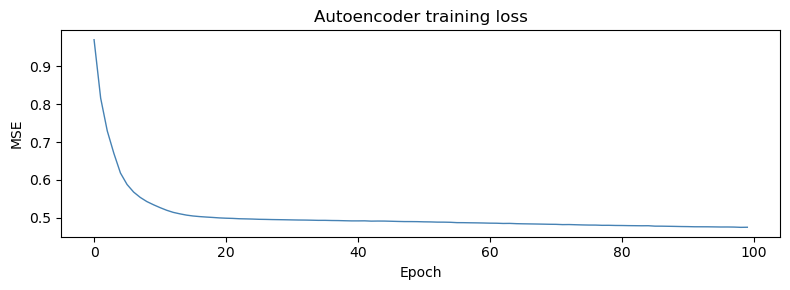

In [21]:
# ── Training loss curve ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(history.history['loss'], color='steelblue', linewidth=1)
ax.set_title('Autoencoder training loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
plt.tight_layout()
plt.savefig('training_loss.png', dpi=120, bbox_inches='tight')
plt.show()


## 14. Reconstruction Error & Anomaly Threshold

For each time point we compute the **mean squared error** between the actual residual and its reconstruction.  
The anomaly threshold is set at: **mean + 3 × std** of the training-period reconstruction error.  
This follows the statistical convention that values beyond 3 standard deviations are genuinely unusual.


In [22]:
# ── Reconstruct & compute per-sample MSE ─────────────────────────────────────
reconstructed = model.predict(X_full_sc, verbose=0)
mse           = np.mean((X_full_sc - reconstructed) ** 2, axis=1)
mse_series    = pd.Series(mse, index=residuals_clipped.index)

# ── Threshold from training period ───────────────────────────────────────────
train_mse = mse_series['2018-10-01':'2019-04-30']
threshold = train_mse.mean() + 3 * train_mse.std()

anomalies = mse_series[mse_series > threshold]

print(f"Anomaly threshold  : {threshold:.4f}")
print(f"Training MSE mean  : {train_mse.mean():.4f}")
print(f"Training MSE std   : {train_mse.std():.4f}")
print(f"Total flagged      : {len(anomalies):,} / {len(mse_series):,} ({len(anomalies)/len(mse_series)*100:.1f}%)")


Anomaly threshold  : 1.7614
Training MSE mean  : 0.4750
Training MSE std   : 0.4288
Total flagged      : 6,137 / 11,328 (54.2%)


## 15. Results

The plot below shows the reconstruction error over the full 15-month monitoring period.  
- **Blue line** — MSE at each time point  
- **Red dashed line** — anomaly threshold (mean + 3σ from training period)  
- **Red shading** — flagged anomaly regions  
- **Orange band** — approximate retrofitting period (May–September 2019)

The model correctly identifies a sustained anomaly corresponding to the known bridge retrofitting event.  
The post-repair period also shows elevated error because the bridge settled at a slightly different frequency baseline — consistent with a physical change in structural state.


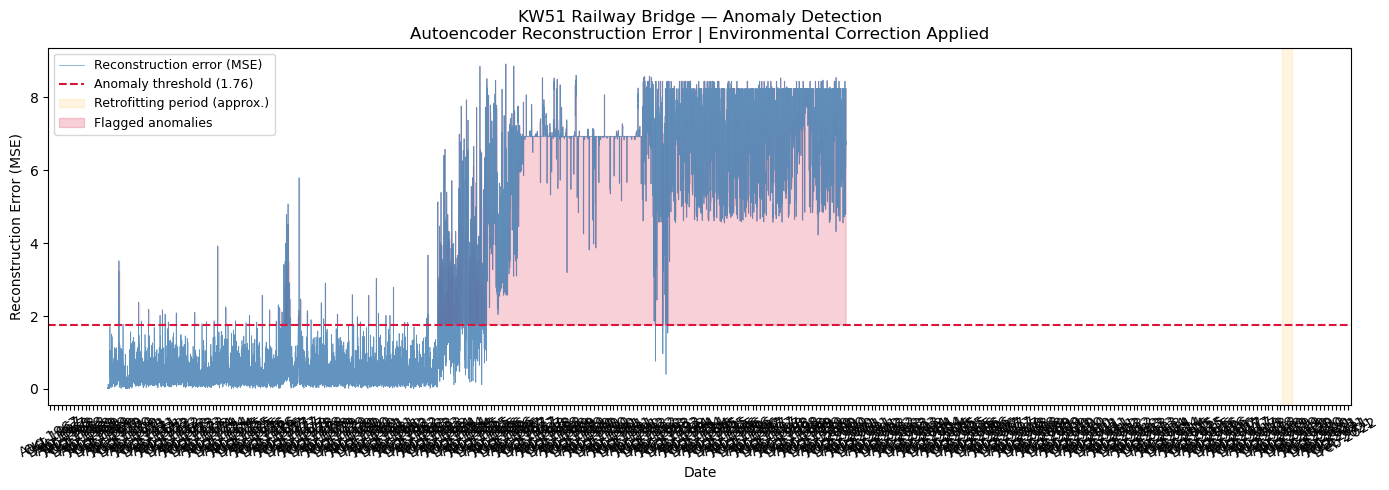

Final plot saved as anomaly_detection_result.png


In [26]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(mse_series.index, mse_series.values,
        linewidth=0.5, color='steelblue', alpha=0.85, label='Reconstruction error (MSE)')

ax.axhline(y=threshold, color='crimson', linewidth=1.5,
           linestyle='--', label=f'Anomaly threshold ({threshold:.2f})')

ax.axvspan(mdates.date2num(pd.Timestamp('2019-05-01')), mdates.date2num(pd.Timestamp('2019-09-30')),
           alpha=0.12, color='orange', label='Retrofitting period (approx.)')

ax.fill_between(mse_series.index, mse_series.values, threshold,
                where=(mse_series.values > threshold),
                color='crimson', alpha=0.2, label='Flagged anomalies')

ax.set_title(
    'KW51 Railway Bridge — Anomaly Detection\n'
    'Autoencoder Reconstruction Error | Environmental Correction Applied',
    fontsize=12
)
ax.set_xlabel('Date')
ax.set_ylabel('Reconstruction Error (MSE)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('anomaly_detection_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final plot saved as anomaly_detection_result.png")


In [24]:
total   = len(mse_series)
flagged = (mse_series > threshold).sum()

print("=" * 50)
print("  KW51 BRIDGE — ANOMALY DETECTION SUMMARY")
print("=" * 50)
print(f"  Dataset         : KW51 Railway Bridge, Leuven")
print(f"  Monitoring      : Oct 2018 – Jan 2020")
print(f"  Time points     : {total:,} (hourly)")
print(f"  Frequency modes : 8  (f3, f5, f6, f9–f13)")
print(f"  Env. variables  : 8")
print()
print(f"  Training period : Oct 2018 – Apr 2019")
print(f"  Env. correction : Random Forest Regression")
print(f"  Anomaly model   : Dense Autoencoder (8→6→3→6→8)")
print()
print(f"  Threshold       : {threshold:.4f}  (mean + 3σ)")
print(f"  Flagged points  : {flagged:,} / {total:,}  ({flagged/total*100:.1f}%)")
print()
print(f"  Key finding     : Sustained anomaly detected from")
print(f"                    ~May 2019, consistent with known")
print(f"                    bridge retrofitting event.")
print("=" * 50)


  KW51 BRIDGE — ANOMALY DETECTION SUMMARY
  Dataset         : KW51 Railway Bridge, Leuven
  Monitoring      : Oct 2018 – Jan 2020
  Time points     : 11,328 (hourly)
  Frequency modes : 8  (f3, f5, f6, f9–f13)
  Env. variables  : 8

  Training period : Oct 2018 – Apr 2019
  Env. correction : Random Forest Regression
  Anomaly model   : Dense Autoencoder (8→6→3→6→8)

  Threshold       : 1.7614  (mean + 3σ)
  Flagged points  : 6,137 / 11,328  (54.2%)

  Key finding     : Sustained anomaly detected from
                    ~May 2019, consistent with known
                    bridge retrofitting event.
